# Global Superstore Sales Performance Analysis

#### Step 1 – Load the Excel and inspect

In [3]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

# Load the Excel file (adjust sheet name if needed)
df = pd.read_excel("d:/Futureinterns/Global_Superstore.xls", sheet_name="Orders")


print(df.shape)
print(df.info())
print(df.head())

(51290, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object    

#### Step 2 – Column renaming and standardization

In [2]:
# Rename columns to lowercase and snake_case
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'city', 'state', 'country', 'postal_code', 'market', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority']


#### Step 3 – Handle missing values

In [3]:
print("Missing values before:")
print(df.isnull().sum())

# Drop rows where key business fields are missing
df = df.dropna(subset=["order_id", "customer_name", "sales", "profit"])
print(f"Rows after dropping key nulls: {len(df)}")

# For remaining columns, fill with reasonable defaults
df["ship_mode"] = df["ship_mode"].fillna("Unknown")
df["segment"] = df["segment"].fillna("Unknown")
df["city"] = df["city"].fillna("Unknown")
df["state"] = df["state"].fillna("Unknown")
df["postal_code"] = df["postal_code"].fillna("Unknown")

Missing values before:
row_id                0
order_id              0
order_date            0
ship_date             0
ship_mode             0
customer_id           0
customer_name         0
segment               0
city                  0
state                 0
country               0
postal_code       41296
market                0
region                0
product_id            0
category              0
sub-category          0
product_name          0
sales                 0
quantity              0
discount              0
profit                0
shipping_cost         0
order_priority        0
dtype: int64
Rows after dropping key nulls: 51290


#### Step 4 – Fix data types

In [4]:
# Convert date columns (adjust names if your dataset uses e.g. "Order Date" vs "order_date")
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")

# Ensure sales, profit, quantity are numeric
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["profit"] = pd.to_numeric(df["profit"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

# Recreate any missing numeric columns
df["profit_per_unit"] = df["profit"] / df["quantity"]
df["profit_margin"] = (df["profit"] / df["sales"]).where(df["sales"] != 0)

#### Step 5 – Add useful KPI columns

In [5]:
# Year, quarter, month for time‑based KPIs
df["order_year"] = df["order_date"].dt.year
df["order_quarter"] = df["order_date"].dt.quarter
df["order_month"] = df["order_date"].dt.month
df["order_year_month"] = df["order_date"].dt.to_period("M").astype(str)

# Delivery days
df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days

#### Step 6 – Remove duplicates

In [6]:
df_dedup = df.drop_duplicates(subset=["order_id"], keep="first")
print(f"Rows after deduplication: {len(df_dedup)}")

Rows after deduplication: 25035


#### Step 7 – Filter and clean outliers (business‑aware)

In [7]:
df_clean = df_dedup.copy()

# Filter clearly wrong values
df_clean = df_clean[df_clean["sales"] > 0]
df_clean = df_clean[df_clean["profit"].notna()]
df_clean = df_clean[df_clean["delivery_days"] >= 0]

# Optionally cap extreme delivery days (e.g., > 100 days)
df_clean.loc[df_clean["delivery_days"] > 100, "delivery_days"] = 100

print(f"Final cleaned rows: {len(df_clean)}")

Final cleaned rows: 25035


#### Step 8 – Export cleaned CSV

In [8]:
df_clean.to_csv("cleaned_global_superstore.csv", index=False)
print("Cleaned data exported to cleaned_global_superstore.csv")

Cleaned data exported to cleaned_global_superstore.csv


In [12]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("output", exist_ok=True)

# Load dataset
file_path = "cleaned_global_superstore.csv"
df = pd.read_csv(file_path, encoding="utf-8", low_memory=False)

# Detect important columns
required_guess = {
    "sales": None,
    "profit": None,
    "order_date": None,
    "product_name": None,
    "category": None,
    "sub_category": None,
    "region": None
}

for c in df.columns:
    cl = c.lower().strip().replace("-", " ").replace("_", " ")
    if cl == "sales":
        required_guess["sales"] = c
    elif cl == "profit":
        required_guess["profit"] = c
    elif cl in ["order date", "orderdate"]:
        required_guess["order_date"] = c
    elif cl in ["product name", "productname"]:
        required_guess["product_name"] = c
    elif cl == "category":
        required_guess["category"] = c
    elif cl in ["sub category", "subcategory"]:
        required_guess["sub_category"] = c
    elif cl == "region":
        required_guess["region"] = c

sales_col = required_guess["sales"]
profit_col = required_guess["profit"]
order_date_col = required_guess["order_date"]
product_col = required_guess["product_name"]
category_col = required_guess["category"]
subcat_col = required_guess["sub_category"]
region_col = required_guess["region"]


In [13]:
# Clean data
for col in [sales_col, profit_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[order_date_col] = pd.to_datetime(df[order_date_col], errors="coerce")
df = df.dropna(subset=[sales_col, order_date_col])

df["year_month"] = df[order_date_col].dt.to_period("M").astype(str)
df["year"] = df[order_date_col].dt.year

(array([-10.,   0.,  10.,  20.,  30.,  40.,  50.]),
 [Text(-10.0, 0, '2014-03'),
  Text(0.0, 0, '2011-01'),
  Text(10.0, 0, '2011-11'),
  Text(20.0, 0, '2012-09'),
  Text(30.0, 0, '2013-07'),
  Text(40.0, 0, '2014-05'),
  Text(50.0, 0, '')])

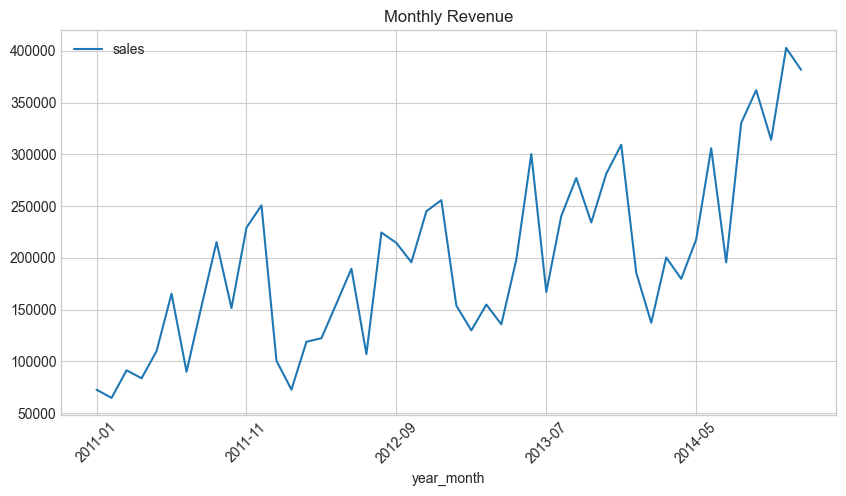

In [15]:
# Revenue trends
monthly = df.groupby("year_month", as_index=False)[sales_col].sum().sort_values("year_month")
yearly = df.groupby("year", as_index=False)[sales_col].sum().sort_values("year")
monthly.plot(x="year_month", y=sales_col, kind="line", title="Monthly Revenue", figsize=(10, 5))
plt.xticks(rotation=45) 

In [18]:
# Top-selling products
product_sales = (
    df.groupby(product_col, as_index=False)
      .agg(revenue=(sales_col, "sum"),
           profit=(profit_col, "sum"),
           orders=(product_col, "count"))
      .sort_values("revenue", ascending=False)
)
top_products = product_sales.head(10)
print(top_products)

                                           product_name     revenue  \
291                        Apple Smart Phone, Full Size  81632.3086   
912                        Cisco Smart Phone, Full Size  73184.5806   
2307                    Motorola Smart Phone, Full Size  71613.8470   
2383                       Nokia Smart Phone, Full Size  70183.7105   
1747         Hon Executive Leather Armchair, Adjustable  56723.2551   
813               Canon imageCLASS 2200 Advanced Copier  50399.8560   
2510  Office Star Executive Leather Armchair, Adjust...  45493.7080   
2384                  Nokia Smart Phone, with Caller ID  44108.2167   
1627  Harbour Creations Executive Leather Armchair, ...  41922.8700   
2854                      Samsung Smart Phone, Cordless  40672.3500   

          profit  orders  
291    5509.9886      46  
912   16522.1206      36  
2307  17522.0470      35  
2383  10460.9305      45  
1747   5651.7351      47  
813   21279.9392       4  
2510   3300.9580      39  
23

In [20]:
# High-value categories
category_perf = (
    df.groupby(category_col, as_index=False)
      .agg(revenue=(sales_col, "sum"),
           profit=(profit_col, "sum"),
           orders=(category_col, "count"))
      .sort_values("revenue", ascending=False)
)

subcat_perf = (
    df.groupby([category_col, subcat_col], as_index=False)
      .agg(revenue=(sales_col, "sum"),
           profit=(profit_col, "sum"),
           orders=(subcat_col, "count"))
      .sort_values("revenue", ascending=False)
)
top_subcats = subcat_perf.head(10)
print(category_perf)
print(top_subcats)

          category       revenue        profit  orders
2       Technology  3.742772e+06  543364.59698    6352
0        Furniture  3.264660e+06  216939.21180    6056
1  Office Supplies  2.468848e+06  329609.96110   12627
           category sub-category       revenue        profit  orders
16       Technology       Phones  1.379157e+06  180023.21920    2148
14       Technology      Copiers  1.248979e+06  219013.15138    1625
1         Furniture       Chairs  1.196113e+06  108643.98230    2240
0         Furniture    Bookcases  1.195011e+06  129928.87850    1745
4   Office Supplies   Appliances  8.398035e+05  116822.15260    1114
11  Office Supplies      Storage  7.870063e+05   76452.26760    2649
3         Furniture       Tables  6.530664e+05  -46496.10030     673
15       Technology     Machines  5.964636e+05   48479.66030     954
13       Technology  Accessories  5.181731e+05   95848.56610    1625
6   Office Supplies      Binders  2.800554e+05   44268.29140    2131


In [ ]:
# Regional performance
region_perf = (
    df.groupby(region_col, as_index=False)
      .agg(revenue=(sales_col, "sum"),
           profit=(profit_col, "sum"),
           orders=(region_col, "count"))
      .sort_values("revenue", ascending=False)
)

region_perf["profit_margin_pct"] = np.where(
    region_perf["revenue"] != 0,
    region_perf["profit"] / region_perf["revenue"] * 100,
    np.nan
)
print(region_perf)

            region       revenue        profit  orders  profit_margin_pct
3          Central  2.066692e+06  212324.10840    5237          10.273620
10           South  1.177092e+06   99544.89878    3256           8.456847
7            North  9.346556e+05  148086.11304    2353          15.843924
9          Oceania  8.417882e+05   92181.90600    1744          10.950724
11  Southeast Asia  6.653635e+05   22410.47040    1517           3.368154
8       North Asia  6.300409e+05  121931.49000    1150          19.352948
5             EMEA  6.100084e+05   33996.84300    2462           5.573177
0           Africa  5.948602e+05   69458.78700    2232          11.676489
12            West  5.693579e+05   80943.36830    1608          14.216605
4     Central Asia  5.686538e+05   95193.46300    1026          16.740145
6             East  5.294907e+05   72024.92920    1398          13.602681
2        Caribbean  2.373730e+05   27774.63276     851          11.700841
1           Canada  5.090244e+04   140

In [22]:
# Save CSV outputs
monthly.to_csv("output/monthly_revenue_trend.csv", index=False)
yearly.to_csv("output/yearly_revenue_trend.csv", index=False)
top_products.to_csv("output/top_selling_products.csv", index=False)
category_perf.to_csv("output/category_performance.csv", index=False)
top_subcats.to_csv("output/top_subcategories.csv", index=False)
region_perf.to_csv("output/regional_performance.csv", index=False)

## Visualization of key findings

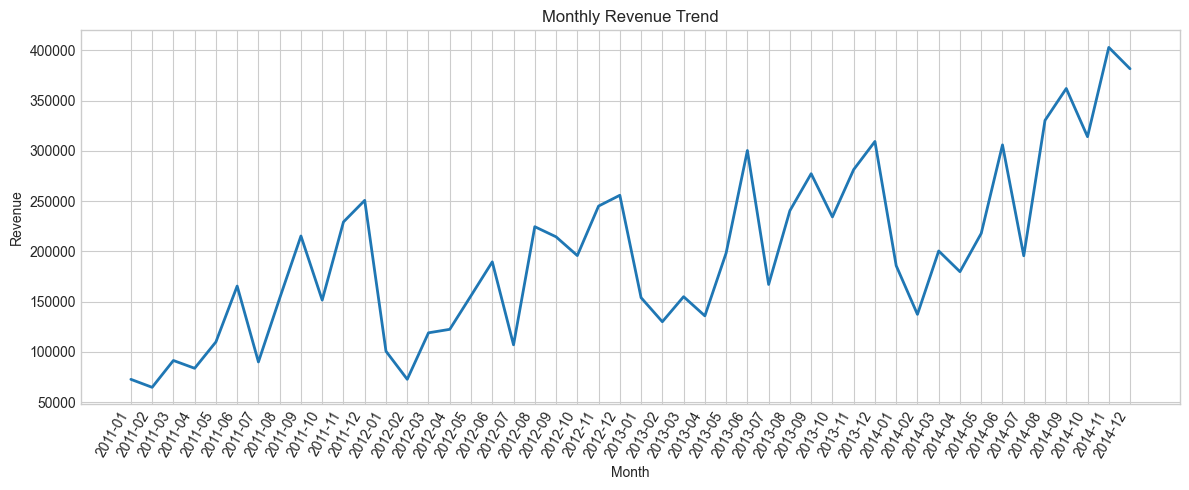

In [26]:
# Plot style
plt.style.use("seaborn-v0_8-whitegrid")

# 1. Monthly revenue trend
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["year_month"], monthly[sales_col], color="#1f77b4", linewidth=2)
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
for label in ax.get_xticklabels():
    label.set_rotation(60)
    label.set_ha("right")
plt.tight_layout()
plt.show()



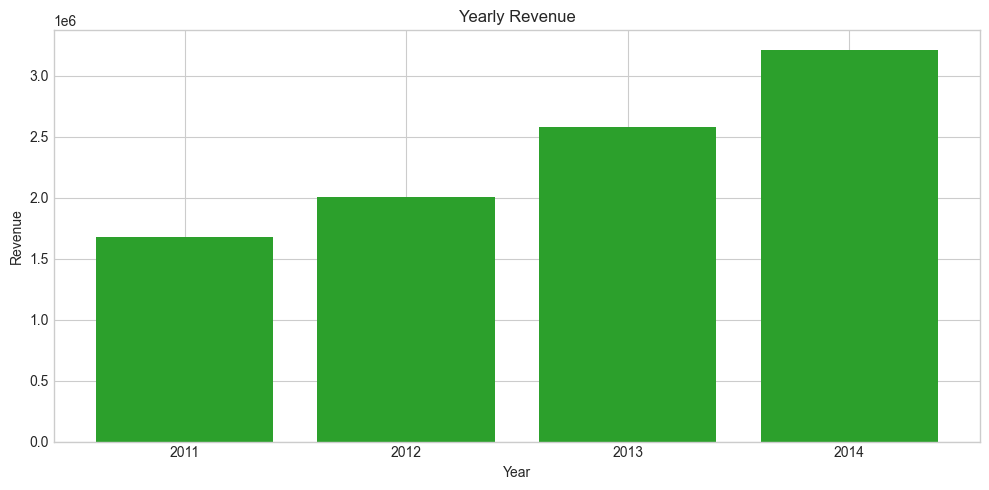

In [27]:
# 2. Yearly revenue
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly["year"].astype(str), yearly[sales_col], color="#2ca02c")
ax.set_title("Yearly Revenue")
ax.set_xlabel("Year")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

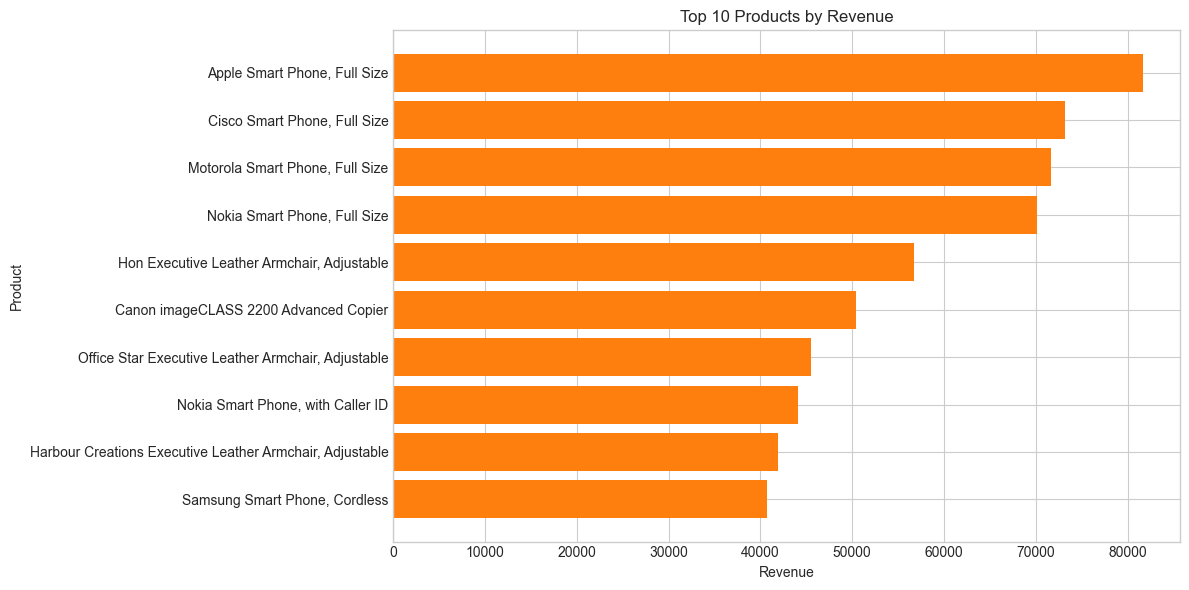

In [28]:
# 3. Top products
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_products[product_col][::-1], top_products["revenue"][::-1], color="#ff7f0e")
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("Product")
plt.tight_layout()
plt.show()


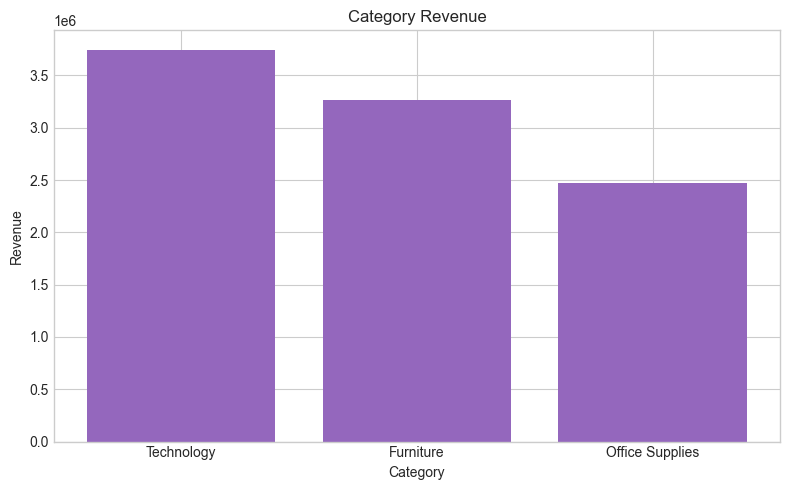

In [29]:
# 4. Category revenue
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(category_perf[category_col], category_perf["revenue"], color="#9467bd")
ax.set_title("Category Revenue")
ax.set_xlabel("Category")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

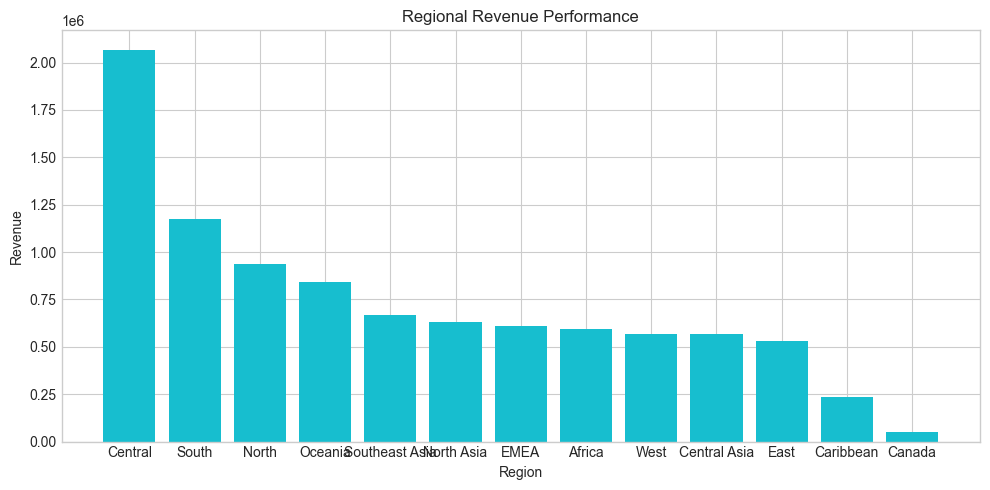

In [30]:
# 5. Regional revenue
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(region_perf[region_col], region_perf["revenue"], color="#17becf")
ax.set_title("Regional Revenue Performance")
ax.set_xlabel("Region")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

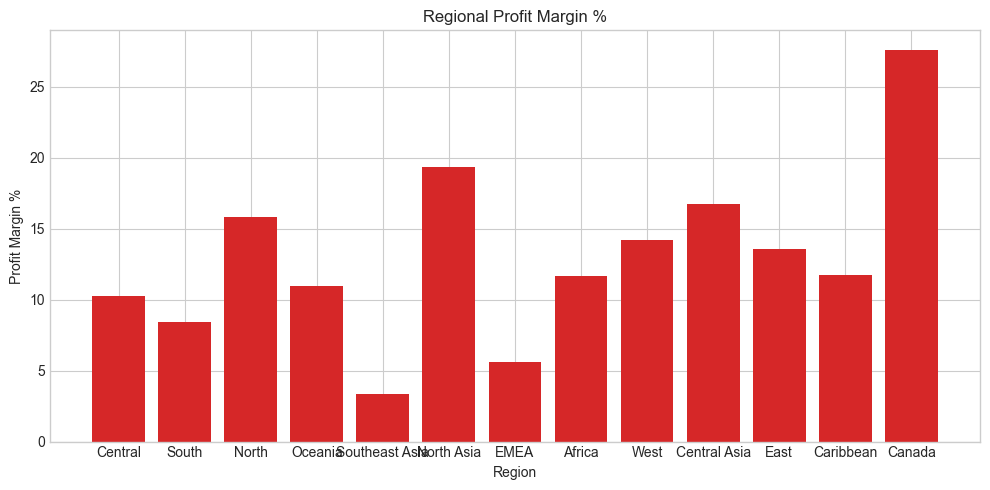

In [31]:
# 6. Regional profit margin
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(region_perf[region_col], region_perf["profit_margin_pct"], color="#d62728")
ax.set_title("Regional Profit Margin %")
ax.set_xlabel("Region")
ax.set_ylabel("Profit Margin %")
plt.tight_layout()
plt.show()

In [32]:
# Key insights
peak_month = monthly.loc[monthly[sales_col].idxmax()]
peak_year = yearly.loc[yearly[sales_col].idxmax()]
top_product = top_products.iloc[0]
top_category = category_perf.iloc[0]
top_region = region_perf.iloc[0]
best_margin_region = region_perf.sort_values("profit_margin_pct", ascending=False).iloc[0]

In [40]:
print("Peak Month:", peak_month["year_month"], "-", peak_month[sales_col])
print("Peak Year:", peak_year["year"], "-", peak_year[sales_col])
print("Top Product:", top_product["product_name"], "-", top_product["revenue"])
print("Top Category:", top_category["category"], "-", top_category["revenue"])
print("Top Region:", top_region["region"], "-", top_region["revenue"])
print("Best Margin Region:", best_margin_region["region"], "-", best_margin_region["profit_margin_pct"], "%")


Peak Month: 2014-11 - 402867.59958
Peak Year: 2014.0 - 3213242.22026
Top Product: Apple Smart Phone, Full Size - 81632.3086
Top Category: Technology - 3742771.82338
Top Region: Central - 2066692.207
Best Margin Region: Canada - 27.587596979633982 %
